In [ ]:
# Load necessary packages
library(dplyr)
library(ggplot2)
library(LeyLabRMisc)
library(data.table)
library(tidyverse)
library(pROC)
library(PRROC)
library(ComplexHeatmap)
library(circlize)
library(Biostrings)
library(scales)
library(boot)

In [16]:
df.dims(6)

# Statistics for contacts between the full genomes

In [ ]:
# Load full list of contacts
full_contacts <- fread('/ebio/abt3_projects2/microc_metagenomics/out/MicroC_binning/mock/full_genomes/norm/Normalized_all_contacts_list.tsv')
colnames(full_contacts) <-c("index1","index2","contacts")
full_contacts

index1,index2,contacts
<chr>,<chr>,<dbl>
B_fragilis_chr,P_nigrescens_chr1,426206.4
B_fragilis_chr,P_nigrescens_chr2,1156102.2
B_fragilis_chr,E_faecium_chr,1293873.2
⋮,⋮,⋮
C_aerofaciens_chr,C_aerofaciens_p1,3077442.2
C_aerofaciens_chr,C_aerofaciens_p2,3136331.8
C_aerofaciens_p1,C_aerofaciens_p2,443659.6


In [ ]:
# Add sequence information (plamsid/chromosome)
full_contacts <- full_contacts %>% mutate(
    index1_is_plasmid = str_detect(index1, "p\\d+$"),
    index2_is_plasmid = str_detect(index2, "p\\d+$")
) %>% 
filter(index1_is_plasmid | index2_is_plasmid) %>%
  filter(!(index1_is_plasmid & index2_is_plasmid))
full_contacts

index1,index2,contacts,index1_is_plasmid,index2_is_plasmid
<chr>,<chr>,<dbl>,<lgl>,<lgl>
B_fragilis_chr,E_faecium_p1,134694.59,FALSE,TRUE
B_fragilis_chr,S_flexneri_p1,21334.14,FALSE,TRUE
B_fragilis_chr,S_flexneri_p2,61391.63,FALSE,TRUE
⋮,⋮,⋮,⋮,⋮
S_flexneri_p4,C_aerofaciens_chr,3869.666,TRUE,FALSE
C_aerofaciens_chr,C_aerofaciens_p1,3077442.229,FALSE,TRUE
C_aerofaciens_chr,C_aerofaciens_p2,3136331.779,FALSE,TRUE


In [ ]:
full_contacts <- full_contacts %>%
  mutate(
    # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
    str_str_bin2 = strsplit(index2, "_")[[1]][1],  # This is wrong — we need to split properly
    str_str_original = strsplit(index1, "_")[[1]][1]
  ) %>%
  mutate(
    str_str_bin2 = str_split_fixed(index2, "_", 2)[, 1],
    str_str_original = str_split_fixed(index1, "_", 2)[, 1]
  ) %>%
  mutate(
    check = str_str_bin2 == str_str_original
  ) %>%
  select(-str_str_bin2, -str_str_original)  # Remove helper columns
full_contacts

index1,index2,contacts,index1_is_plasmid,index2_is_plasmid,check
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>
B_fragilis_chr,E_faecium_p1,134694.59,FALSE,TRUE,FALSE
B_fragilis_chr,S_flexneri_p1,21334.14,FALSE,TRUE,FALSE
B_fragilis_chr,S_flexneri_p2,61391.63,FALSE,TRUE,FALSE
⋮,⋮,⋮,⋮,⋮,⋮
S_flexneri_p4,C_aerofaciens_chr,3869.666,TRUE,FALSE,FALSE
C_aerofaciens_chr,C_aerofaciens_p1,3077442.229,FALSE,TRUE,TRUE
C_aerofaciens_chr,C_aerofaciens_p2,3136331.779,FALSE,TRUE,TRUE


In [ ]:
# Divide true and false contacts
full_contacts_true <- full_contacts %>% filter(check == TRUE) 
full_contacts_false <- full_contacts %>% filter(check == FALSE) 

In [21]:
# Define bootstrap function for median
mean_boot <- function(data, indices) {
  mean(data[indices])
}
# Boostrap the medians for intra and inter contacts
set.seed(123)   # for reproducibility
boot_intra <- boot(full_contacts_true$contacts, statistic = mean_boot, R = 5000)
boot_inter <- boot(full_contacts_false$contacts, statistic = mean_boot, R = 5000)
# Compute 95% confidence intervals
ci_intra <- boot.ci(boot_intra, type = "perc")
ci_inter <- boot.ci(boot_inter, type = "perc")


cat("\nTrue contacts:", nrow(full_contacts_true), "\n")
cat("False contacts:", nrow(full_contacts_false), "\n")
cat(
  sprintf(
    "True contacts mean = %.2f (95%% CI %.2f - %.2f)\n",
    mean(full_contacts_true$contacts),
    ci_intra$percent[4],
    ci_intra$percent[5]
  )
)

cat(
  sprintf(
    "False contacts mean = %.2f (95%% CI %.2f - %.2f)\n",
    mean(full_contacts_false$contacts),
    ci_inter$percent[4],
    ci_inter$percent[5]
  )
)


True contacts: 7 
False contacts: 35 
True contacts mean = 2625158.09 (95% CI 1555577.84 - 4027330.38)
False contacts mean = 26983.47 (95% CI 19241.82 - 36240.41)


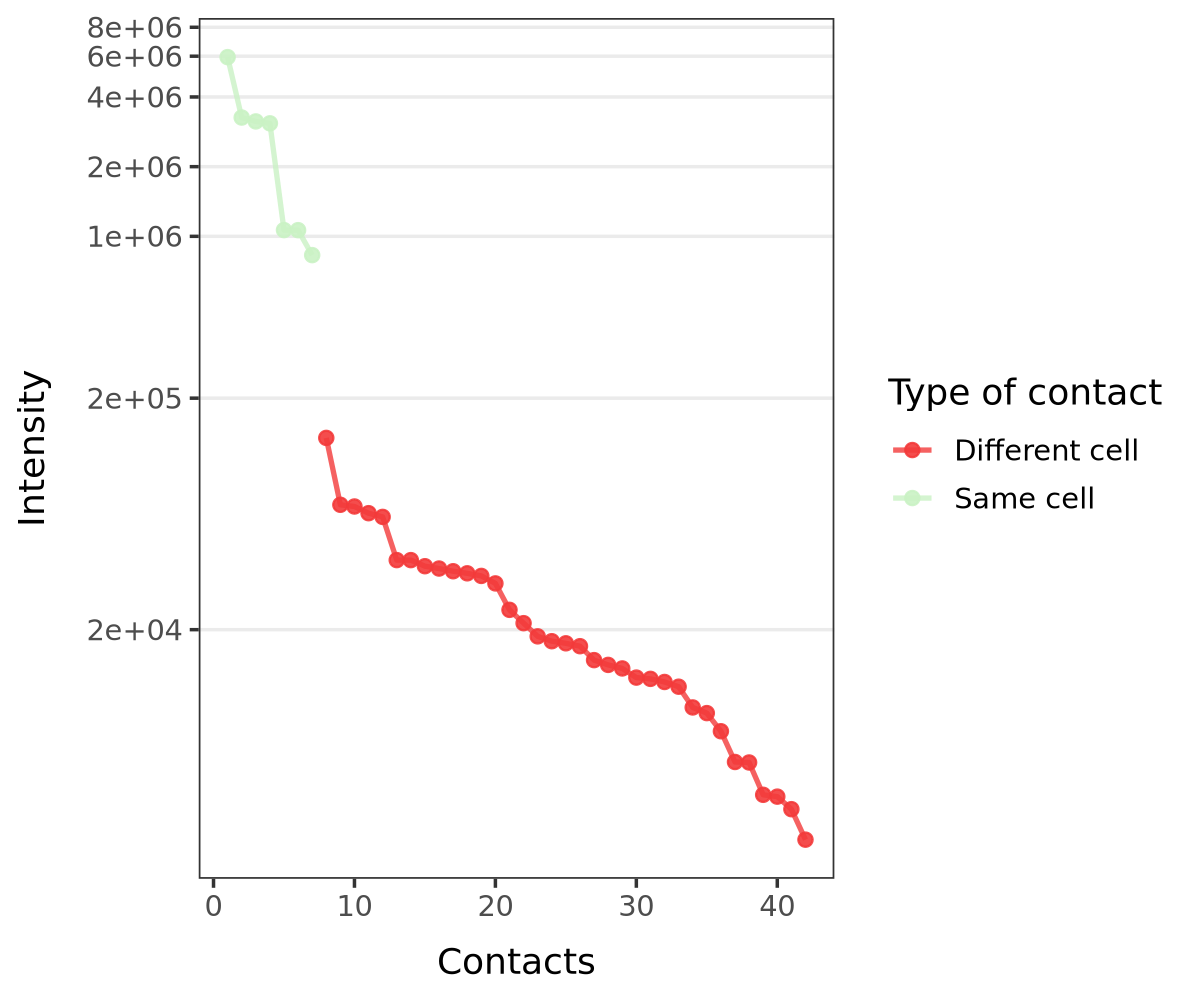

In [ ]:
# Plot contact intensities
p.dims(6,5)
full_contacts %>%
  arrange(desc(contacts)) %>%
  mutate(
    x = seq_along(contacts)#,
  ) %>%
  ggplot(aes(
    x = x,
    y = contacts,
    color = check,
    group = check
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      `TRUE` = "#c9f1c4",
      `FALSE`  = "#f23a3a"
    ),
    labels = c(
      `TRUE` = "Same cell",
      `FALSE`  = "Different cell"
    )
  ) +
  scale_y_continuous(
    trans = pseudo_log_trans(base = 10),
    breaks = c(0, 20000, 200000, 1000000, 2000000, 4000000, 6000000, 8000000),
    labels = scales::label_scientific()
  ) +
  labs(
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_bw(base_size = 13) +
  #theme_minimal(base_size = 17) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )

# Satistics for the permutations

In [ ]:
# Load file containing contacts and bin association of the synthetic contigs
contact_files <- Sys.glob('/ebio/abt3_projects2/microc_metagenomics/out/mock_permutations_contig_generation/permutation_*/norm/Normalized_all_contacts_list.tsv')
binning_files <- Sys.glob('/ebio/abt3_projects2/microc_metagenomics/out/mock_permutations_contig_generation/permutation_*/contig2bin.tsv')

In [ ]:
# Establish belonging of each sequence and type of contact
links_for_thresholds <- list()
for (i in c(1:length(binning_files))){
  contacts.df <- fread(contact_files[i],header = T)
  colnames(contacts.df) <- c("index1","index2","contacts")
  bins.df <- fread(binning_files[i],header =T)
  contacts.df[,bin1:=bins.df$original_sequence[match(contacts.df$index1,bins.df$contig_id)]]
  contacts.df[,bin2:=bins.df$original_sequence[match(contacts.df$index2,bins.df$contig_id)]]
  links_for_thresholds[[i]] <- contacts.df[!is.na(bin1) & !is.na(bin2)]
  links_for_thresholds[[i]][,type:=ifelse(bin1==bin2,'intra','inter')]
}
links_for_thresholds[1]

index1,index2,contacts,bin1,bin2,type
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
contig_1,contig_2,419659.6,B_fragilis_chr,B_fragilis_chr,intra
contig_1,contig_3,138713.1,B_fragilis_chr,B_fragilis_chr,intra
contig_1,contig_4,107811.6,B_fragilis_chr,B_fragilis_chr,intra
⋮,⋮,⋮,⋮,⋮,⋮
contig_244,contig_245,2064.246,E_faecium_p1,S_flexneri_p2,inter
contig_244,contig_246,1660.359,E_faecium_p1,C_aerofaciens_p2,inter
contig_245,contig_246,1141.213,S_flexneri_p2,C_aerofaciens_p2,inter


In [ ]:
# Calculate median of the plasmid - chromosome contacts
medians <- list()
for (i in c(1:length(binning_files))){
    p_m_contacts <- links_for_thresholds[[i]] %>%
      mutate(
        index1_is_plasmid = str_detect(bin1, "p\\d+$"),
        index2_is_plasmid = str_detect(bin2, "p\\d+$")) %>%
      filter(index1_is_plasmid | index2_is_plasmid) %>%
      filter(!(index1_is_plasmid & index2_is_plasmid))
    rows_to_swap <- p_m_contacts$index1_is_plasmid == FALSE
    p_m_contacts[rows_to_swap, c("index1", "index2")] <- p_m_contacts[rows_to_swap, c("index2", "index1")]
    p_m_contacts[rows_to_swap, c("bin1", "bin2")] <- p_m_contacts[rows_to_swap, c("bin2", "bin1")]
    p_m_contacts[rows_to_swap, c("index1_is_plasmid", "index2_is_plasmid")] <- p_m_contacts[rows_to_swap, c("index2_is_plasmid", "index1_is_plasmid")]
    medians[[i]] <- p_m_contacts %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
}
medians[[1]]

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_174,B_fragilis_chr,202.184
contig_174,C_aerofaciens_chr,0.000
contig_174,E_faecium_chr,0.000
⋮,⋮,⋮
contig_246,P_nigrescens_chr1,556.0225
contig_246,P_nigrescens_chr2,1093.2940
contig_246,S_flexneri_chr,632.2040


In [ ]:
# Check which contacts are biologically accurate
for (i in c(1:length(binning_files))){
  bins.df <- fread(binning_files[i],header =T)
  medians[[i]] <- medians[[i]] %>%
    left_join(bins.df, by = c("index1" = "contig_id")) %>%
    mutate(
      # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
      str_str_bin2 = strsplit(bin2, "_")[[1]][1], 
      str_str_original = strsplit(original_sequence, "_")[[1]][1]
    ) %>%
    # Fix: use str_split_fixed or better, use stringr
    mutate(
      str_str_bin2 = str_split_fixed(bin2, "_", 2)[, 1],
      str_str_original = str_split_fixed(original_sequence, "_", 2)[, 1]
    ) %>%
    mutate(
      check = str_str_bin2 == str_str_original
    ) %>%
    select(-str_str_bin2, -str_str_original)
}
medians[[1]]

index1,bin2,median_contacts,original_sequence,check
<chr>,<chr>,<dbl>,<chr>,<lgl>
contig_174,B_fragilis_chr,202.184,S_flexneri_p1,FALSE
contig_174,C_aerofaciens_chr,0.000,S_flexneri_p1,FALSE
contig_174,E_faecium_chr,0.000,S_flexneri_p1,FALSE
⋮,⋮,⋮,⋮,⋮
contig_246,P_nigrescens_chr1,556.0225,C_aerofaciens_p2,FALSE
contig_246,P_nigrescens_chr2,1093.2940,C_aerofaciens_p2,FALSE
contig_246,S_flexneri_chr,632.2040,C_aerofaciens_p2,FALSE


In [ ]:
# Obtain mean of the different types of cntacts per permutation
stats <- data.frame(
  permutation = paste0("permutation_", seq_along(medians)),
  mean_TRUE   = sapply(medians, function(df) mean(df$median_contacts[df$check == TRUE],  na.rm = TRUE)),
  mean_FALSE  = sapply(medians, function(df) mean(df$median_contacts[df$check == FALSE], na.rm = TRUE))
)
stats

permutation,mean_TRUE,mean_FALSE
<chr>,<dbl>,<dbl>
permutation_1,29657.62,194.3728
permutation_2,38044.93,265.8389
permutation_3,24323.75,207.0292
⋮,⋮,⋮
permutation_23,24227.85,221.8445
permutation_24,21719.54,181.8353
permutation_25,76086.51,648.4803


In [ ]:
# Change the data frame to long format for plotting
stats_long <- pivot_longer(
  stats,
  cols = c(mean_TRUE, mean_FALSE),
  names_to = "group",
  values_to = "value"
)

# Set order (True first) and rename for display
stats_long$group <- factor(
  stats_long$group,
  levels = c("mean_TRUE", "mean_FALSE"),
  labels = c("True contacts", "False contacts")
)

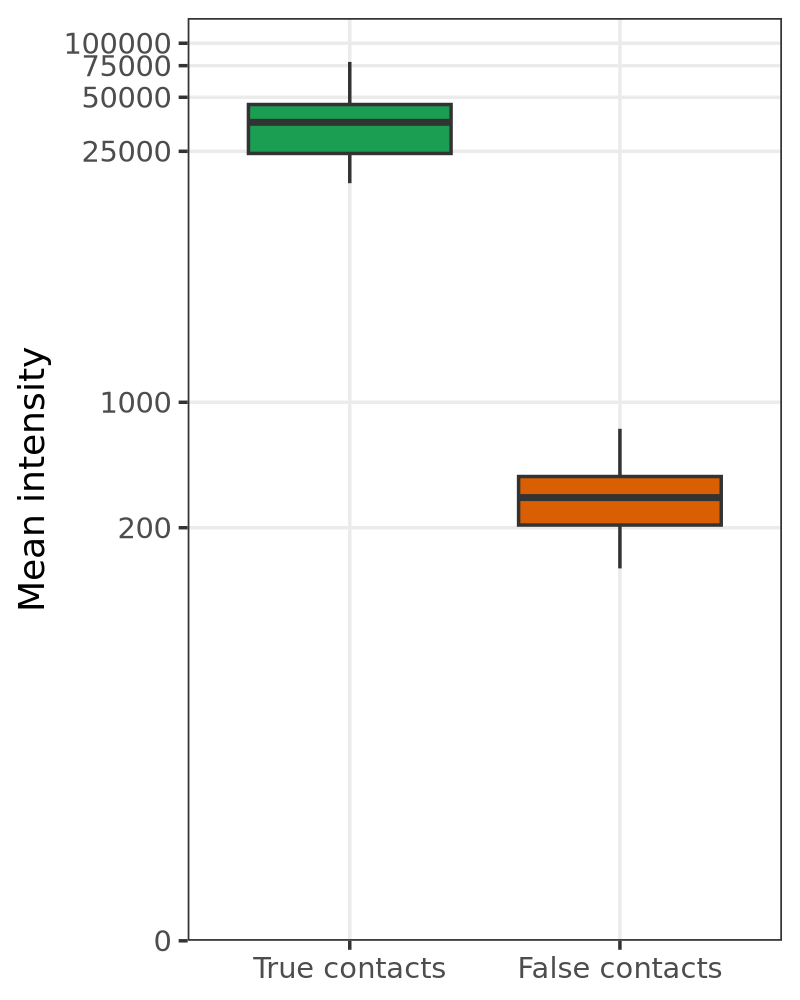

In [ ]:
# Box plot of the comparison of contact intensities
p.dims(4,5)

ggplot(stats_long, aes(x = group, y = value, fill = group)) +
  geom_boxplot() +
  scale_fill_manual(values = c(
    "True contacts" = "#1b9e52",
    "False contacts" = "#d95f02"
  )) +
  scale_y_continuous(
    trans = pseudo_log_trans(base = 10),
    breaks = c(0, 200, 1000, 25000, 50000, 75000, 100000),
    limits = c(0, NA),
    expand = expansion(mult = c(0, 0.05))
  ) +
  labs(
    x = NULL,
    y = "Mean intensity"
  ) +
  theme_bw(base_size = 13) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank()
  )
